In [1]:
using Lux, LuxCUDA
using JLD2
using MAT

using CairoMakie
using ColorTypes
using ImageCore

const BASE="/development/src/julia/autoencoder"

include("$BASE/lib/utils.jl")
using .Utils


- 8x8x128 pretty good
- 4x4x256 some degredation
- 2x2x512

In [2]:
model = nothing
parameters = nothing
state = nothing
@load "$BASE/build/checkpoint/model_10.jld2" model parameters state

3-element Vector{Symbol}:
 :model
 :parameters
 :state

In [3]:
function load()
    Xf = Utils.MMapReader("$BASE/build/Xs.ser")
    yf = open("$BASE/build/ys.ser", "r")
    try    
        open("$BASE/build/count.ser", "r") do io
            N = Utils.deserialize(io, Int64)
    		ys = Vector{Vector{Int}}(undef, N)
            Xs = Vector{AbstractArray{Float32, 4}}(undef, N)
            
            for i ∈ 1:N
                Xs[i] = deserialize(Xf, Array{Float32})
                ys[i] = deserialize(yf, Array{Int64})
            end
            
            return Xs, ys
        end
    finally
        close(Xf)
        close(yf)
    end
end
Xs, ys = load()

display("||Xs|| = $(length(Xs))")
display("||ys|| = $(length(ys))")

"||Xs|| = 10"

"||ys|| = 10"

In [4]:
meta = matread("/data/imagenet/2012/ILSVRC2012_devkit_t12/data/meta.mat")
synsets = meta["synsets"]

# synsets["WNID"]
# synsets["wordnet_height"]
# synsets["num_children"]
# synsets["num_train_images"]
# synsets["ILSVRC2012_ID"]
# synsets["words"]
# synsets["gloss"]
# synsets["children"]

nothing

In [5]:
function makie_image(img)
    img = permutedims(img, (3, 1, 2))
    img = colorview(RGB, img)
    rotr90(img)    
end

makie_image (generic function with 1 method)

"a flexible cap on a baby's feeding bottle or pacifier"

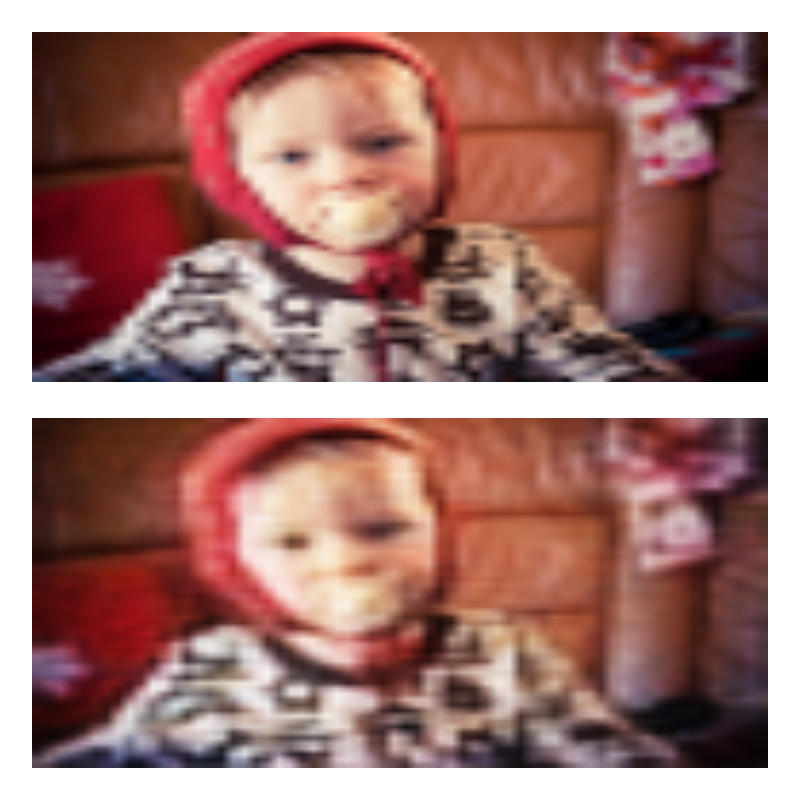

In [6]:
function predict(img)
    x = reshape(img, 64, 64, 3, 1)
    st_eval = Lux.testmode(state)
    ŷ, st_new = Lux.apply(model, x, parameters, st_eval)
    return Array(ŷ)[:, :, :, 1]
end

shard = 5
index = 1001
test_img = Xs[shard][:,:,:,index]
display(synsets["gloss"][ys[shard][index]])

fig = Figure(size=(400,400))
ax1 = Axis(fig[1, 1])
ax2 = Axis(fig[2, 1])
image!(ax1, makie_image(test_img))
image!(ax2, makie_image(predict(test_img)))
hidedecorations!(ax1)
hidespines!(ax1)
hidedecorations!(ax2)
hidespines!(ax2)
fig